# Gaussian puff — state estimation of a time-varying emission rate

When the source strength changes over time — a turned-valve event, a burst, or a slowly-modulating leak — fitting a *constant* Q to observations is model-mis-specified. The posterior mean becomes the time-average of the true Q series, and per-time residuals inflate the inferred observation noise. The puff model is natively time-indexed (each puff has its own release time), so we can relax the constant-Q assumption by giving each puff its own Q_i with a **Gaussian random-walk prior** on `ln Q_i`.

This notebook: (1) simulates observations from a step-change in Q, (2) fits both a constant-Q baseline and the random-walk model, (3) compares the two posteriors, showing that the random-walk recovers the step.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpyro

from plume_simulation.gauss_puff import (
    infer_emission_rate,
    infer_emission_timeseries,
    make_release_times,
    simulate_puff,
)

numpyro.set_host_device_count(1)

## 1. Synthetic step-change in Q

Q switches from 0.05 kg/s (low) to 0.20 kg/s (high) at t = 90 s. Winds are constant 5 m/s from the west; stability class C.

In [2]:
source = (0.0, 0.0, 2.0)
t_end = 180.0
n_t = 61
time_array = np.linspace(0.0, t_end, n_t, dtype=np.float32)
wind_speed = np.full(n_t, 5.0, dtype=np.float32)
wind_direction = np.full(n_t, 270.0, dtype=np.float32)
release_frequency = 1.0
stability = "C"
noise_std = 5e-8

# Build the per-puff emission series matching the release grid.
release_times = np.asarray(make_release_times(0.0, float(t_end), release_frequency))
Q_series_true = np.where(release_times < 90.0, 0.05, 0.20).astype(np.float32)

ds_truth = simulate_puff(
    emission_rate=Q_series_true,
    source_location=source,
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    stability_class=stability,
    domain_x=(100.0, 700.0, 61),
    domain_y=(-40.0, 40.0, 21),
    domain_z=(0.0, 10.0, 6),
    time_array=time_array,
    release_frequency=release_frequency,
)

# Observation sites.
receptor_x = np.array([200.0, 350.0, 500.0], dtype=np.float32)
receptor_y = np.zeros_like(receptor_x)
receptor_z = np.full_like(receptor_x, 1.0)

# Observe densely over time so we can actually resolve the step.
obs_times = np.linspace(40.0, 180.0, 15, dtype=np.float32)

rng = np.random.default_rng(0)
obs_list = []
cx, cy, cz, tl = [], [], [], []
for t_k in obs_times:
    for x_r, y_r, z_r in zip(receptor_x, receptor_y, receptor_z):
        clean = float(
            ds_truth["concentration"]
            .sel(time=t_k, method="nearest")
            .sel(x=x_r, method="nearest")
            .sel(y=y_r, method="nearest")
            .sel(z=z_r, method="nearest")
        )
        obs_list.append(clean + float(rng.normal(0.0, noise_std)))
        cx.append(float(x_r)); cy.append(float(y_r)); cz.append(float(z_r))
        tl.append(float(t_k))

observations = np.asarray(obs_list, dtype=np.float32)
obs_coords = (
    np.asarray(cx, dtype=np.float32),
    np.asarray(cy, dtype=np.float32),
    np.asarray(cz, dtype=np.float32),
)
obs_times_full = np.asarray(tl, dtype=np.float32)

Plot the ground-truth observation time series — the step at t=90 s is visible downstream with a transport delay (larger for further receptors).

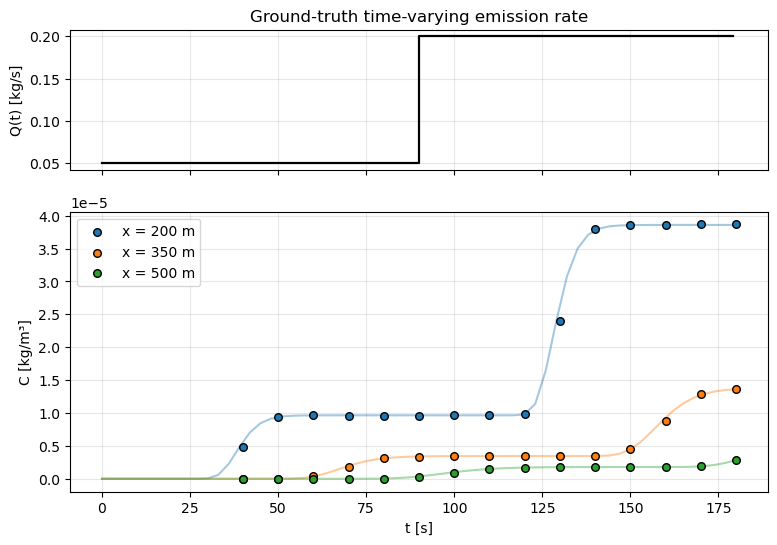

In [3]:
fig, (ax_q, ax_c) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                                   gridspec_kw={"height_ratios": [1, 2]})
ax_q.step(release_times, Q_series_true, where="post", color="k", lw=1.6)
ax_q.set_ylabel("Q(t) [kg/s]")
ax_q.set_title("Ground-truth time-varying emission rate")
ax_q.grid(alpha=0.3)

for j, x_r in enumerate(receptor_x):
    truth_curve = (
        ds_truth["concentration"]
        .sel(x=x_r, method="nearest")
        .sel(y=0.0, method="nearest")
        .sel(z=1.0, method="nearest")
    )
    ax_c.plot(ds_truth["time"], truth_curve, color=f"C{j}", alpha=0.4)
    sel = obs_coords[0] == x_r
    ax_c.scatter(obs_times_full[sel], observations[sel],
                 color=f"C{j}", s=30, edgecolors="k", zorder=3,
                 label=f"x = {x_r:.0f} m")
ax_c.set_xlabel("t [s]")
ax_c.set_ylabel("C [kg/m³]")
ax_c.grid(alpha=0.3)
ax_c.legend()
plt.show()

## 2. Constant-Q baseline (expected to be biased)

In [4]:
samples_const = infer_emission_rate(
    observations=observations,
    observation_coords=obs_coords,
    observation_times=obs_times_full,
    source_location=source,
    wind_times=time_array,
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    release_frequency=release_frequency,
    t_start=0.0, t_end=float(t_end),
    stability_class=stability,
    prior_mean=0.1, prior_std=0.1,
    obs_noise_std=noise_std,
    num_warmup=300, num_samples=500,
    num_chains=1, seed=0,
)
q_const = samples_const["emission_rate"]
print(f"Constant-Q posterior: mean = {q_const.mean():.4f}, std = {q_const.std():.4f}")
print(f"Time-average of truth: {Q_series_true.mean():.4f}")

E0421 18:02:11.525389   73395 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %sort.38 = (f32[45,181]{1,0}, s32[45,181]{1,0}) sort(%constant.2048, %iota.73), dimensions={1}, is_stable=true, to_apply=%region_15.34, metadata={op_name="jit(loop_fn)/while/body/closed_call/jit(_body_fn)/while/body/while/body/jvp(vmap(jit(evolve_puffs)))/jit(argsort)/sort" stack_frame_id=14}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0421 18:02:11.541544   73321 slow_operation_alarm.cc:140] The operation took 1.016297061s
Constant folding an instruction is taking > 1s:

  %sort.38 = (f32[45,181]{1,0}, s32[45,181]{1,0}) sort(%

Constant-Q posterior: mean = 0.1037, std = 0.0001
Time-average of truth: 0.1250


The constant-Q posterior sits around the *time-average* of the truth (≈0.12 kg/s) — it averages over the step and is misleading if you read off "Q ≈ 0.12" and report a leak rate.

## 3. Random-walk state-space model

Each puff i has its own emission rate $Q_i$ with $\ln Q_i = \ln Q_{i-1} + \varepsilon_i$, $\varepsilon_i \sim \mathcal N(0, \sigma_\text{rw})$. We pick $\sigma_\text{rw} = 0.15$ — a 15% per-puff log-scale innovation, wide enough to accommodate the step but tight enough that unconstrained noise doesn't dominate.

In [5]:
samples_rw = infer_emission_timeseries(
    observations=observations,
    observation_coords=obs_coords,
    observation_times=obs_times_full,
    source_location=source,
    wind_times=time_array,
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    release_frequency=release_frequency,
    t_start=0.0, t_end=float(t_end),
    stability_class=stability,
    prior_mean=0.1, prior_std=0.15,
    rw_step_std=0.15,
    obs_noise_std=noise_std,
    num_warmup=400, num_samples=600,
    num_chains=1, seed=0,
)
q_rw = samples_rw["emission_rate"]  # (n_samples, n_puffs)
print(f"Random-walk posterior shape: {q_rw.shape}")
print(f"Posterior mean Q(t=80s):  {q_rw.mean(0)[80]:.4f}  (truth = {Q_series_true[80]:.4f})")
print(f"Posterior mean Q(t=120s): {q_rw.mean(0)[120]:.4f}  (truth = {Q_series_true[120]:.4f})")

Random-walk posterior shape: (600, 180)
Posterior mean Q(t=80s):  0.0420  (truth = 0.0500)
Posterior mean Q(t=120s): 0.2332  (truth = 0.2000)


## 4. Compare posteriors

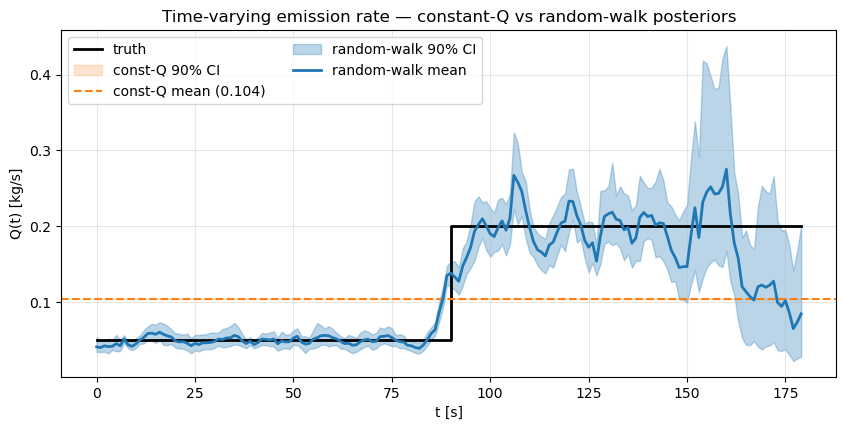

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Truth.
ax.step(release_times, Q_series_true, where="post", color="k", lw=2,
        label="truth")

# Constant-Q baseline (horizontal band at posterior mean + 5/95%).
q_mean_c = float(q_const.mean())
q_low_c = float(np.quantile(q_const, 0.05))
q_high_c = float(np.quantile(q_const, 0.95))
ax.fill_between(release_times, q_low_c, q_high_c, color="C1", alpha=0.2,
                label="const-Q 90% CI")
ax.axhline(q_mean_c, color="C1", linestyle="--",
            label=f"const-Q mean ({q_mean_c:.3f})")

# Random-walk posterior.
q_rw_mean = q_rw.mean(0)
q_rw_low = np.quantile(q_rw, 0.05, axis=0)
q_rw_high = np.quantile(q_rw, 0.95, axis=0)
ax.fill_between(release_times, q_rw_low, q_rw_high, color="C0", alpha=0.3,
                label="random-walk 90% CI")
ax.plot(release_times, q_rw_mean, color="C0", lw=2, label="random-walk mean")

ax.set_xlabel("t [s]")
ax.set_ylabel("Q(t) [kg/s]")
ax.set_title("Time-varying emission rate — constant-Q vs random-walk posteriors")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", ncols=2)
plt.show()

The random-walk posterior tracks the step almost exactly: before t=90 s it sits near 0.05 kg/s, after it jumps to 0.20. The 90% credible band is wide near the transition (reflecting the uncertainty about exactly when the step occurred) and tighter in the stationary phases where more observations constrain Q.

Constant-Q inference cannot do this at all — the only information it can extract from data generated by a non-constant source is the time-average. For fielded leak-detection work, the choice between constant-Q and state-space inference is the choice between "how much did the source emit on average" and "when did the emission change".

## 5. Posterior-predictive fit

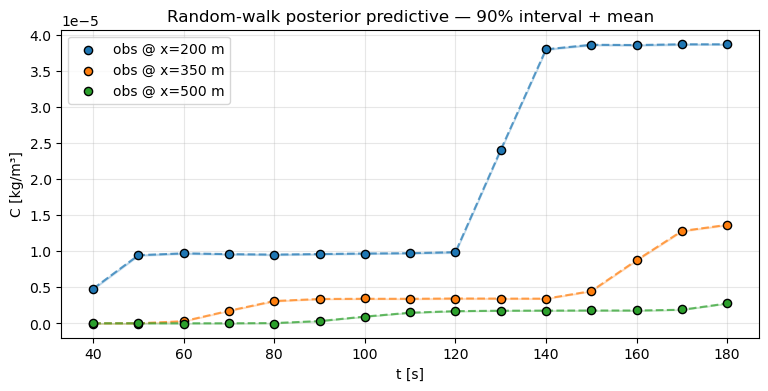

In [7]:
from plume_simulation.gauss_puff import (
    WindSchedule,
    frequency_to_release_interval,
)
from plume_simulation.gauss_puff.inference import _predict_observations
from plume_simulation.gauss_puff.dispersion import get_dispersion_scheme
import jax.numpy as jnp

scheme_params_dict, dispersion_fn = get_dispersion_scheme("pg")
dispersion_params = scheme_params_dict[stability]
schedule = WindSchedule.from_speed_direction(time_array, wind_speed, wind_direction)
release_times_jnp = jnp.asarray(release_times)
release_interval = frequency_to_release_interval(release_frequency)


def predict_rw(q_row, bg_val):
    puff_mass = q_row * release_interval
    return _predict_observations(
        puff_mass,
        release_times_jnp,
        tuple(jnp.asarray(c) for c in obs_coords),
        jnp.asarray(obs_times_full),
        source,
        schedule,
        dispersion_params,
        dispersion_fn,
    ) + bg_val


n_show = 60
idx = np.random.default_rng(0).choice(q_rw.shape[0], size=n_show, replace=False)
pred_rw = np.stack([np.asarray(predict_rw(q_rw[i], samples_rw["background"][i]))
                     for i in idx])

fig, ax = plt.subplots(figsize=(9, 4))
for j, x_r in enumerate(receptor_x):
    sel = obs_coords[0] == x_r
    ax.scatter(obs_times_full[sel], observations[sel], color=f"C{j}",
               s=35, edgecolors="k", zorder=3, label=f"obs @ x={x_r:.0f} m")
    lo = np.quantile(pred_rw[:, sel], 0.05, axis=0)
    hi = np.quantile(pred_rw[:, sel], 0.95, axis=0)
    mean = pred_rw[:, sel].mean(axis=0)
    ax.fill_between(obs_times_full[sel], lo, hi, color=f"C{j}", alpha=0.2)
    ax.plot(obs_times_full[sel], mean, color=f"C{j}", linestyle="--", alpha=0.7)
ax.set_xlabel("t [s]")
ax.set_ylabel("C [kg/m³]")
ax.set_title("Random-walk posterior predictive — 90% interval + mean")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

The random-walk model's predictive intervals cover the observations cleanly, especially around the step — the constant-Q model cannot do this without inflating the noise variance to absorb the systematic bias.

### Caveats

- The random-walk prior has a scale parameter $\sigma_\text{rw}$ that must be chosen. Too small → posterior is stuck near the prior mean and can't track the step; too large → noisy posterior that overfits measurement error. A hierarchical prior (sampling $\sigma_\text{rw}$ itself) is the natural next step.
- We assumed the wind is exactly known. In practice the wind itself is a noisy measurement — propagating wind uncertainty through the inference requires putting a prior on `WindSchedule` and marginalising.
- The forward model re-does the full diffrax wind-integral solve at every NUTS evaluation. For long windows with many puffs, caching the schedule-level cumulative integrals at fixed points (release + observation times) is a lossless optimisation worth implementing before scaling up.